# **Earthquake in Indonesia 2026-08**

![](https://www.cnn.co.jp/storage/2026/08/15/2cd6289135549cd199f526643e831d80/c-gettyimages-2289998296__1200_.jpeg)

A magnitude 7.7 earthquake struck central Indonesia on the morning of the 15th (local time), and authorities issued a tsunami warning.

### **Datasource**
* The data was acquired through [the USGS Earthquake Catalog](https://earthquake.usgs.gov/earthquakes/search/)

In [1]:
import os
import numpy as np
import pandas as pd
import random
import folium
from folium import plugins
import seaborn as sns
import cv2
import matplotlib.pyplot as plt
import IPython
import time
import plotly.express as px
from mpl_toolkits.mplot3d import Axes3D
from branca.colormap import linear

In [2]:
data0=pd.read_csv('/kaggle/input/datasets/stpeteishii/earthquake-in-japan/indonesia_202608.csv')
print(data0.columns.tolist())

['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type', 'horizontalError', 'depthError', 'magError', 'magNst', 'status', 'locationSource', 'magSource']


### Custom Rectangle
    * [-16.436, 22.948] Latitude
    * [88.682, 145.283] Longitude

In [3]:
data1=data0[['time','latitude','longitude','depth','mag',]]
display(data1)

,time,latitude,longitude,depth,mag
0,2026-07-16T01:15:27.405Z,19.6364,121.4422,10.000,4.8
1,2026-07-16T05:55:39.453Z,4.9221,125.2999,10.007,4.7
2,2026-07-16T07:49:10.570Z,22.8421,144.3516,18.081,5.3
3,2026-07-16T11:30:19.266Z,-6.8299,131.0765,35.000,4.5
4,2026-07-16T16:46:32.801Z,5.3632,125.0902,86.358,4.4
...,...,...,...,...,...
238,2026-08-15T09:51:45.571Z,-0.1583,122.0236,272.756,4.6
239,2026-08-15T10:31:30.185Z,-8.2640,120.3675,10.000,5.1
240,2026-08-15T10:54:51.796Z,3.0856,99.0150,172.526,6.9
241,2026-08-15T11:10:24.937Z,-4.4110,143.9212,120.214,5.4


In [4]:
display(data1[data1['mag']>=6.0])
idxs=data1[data1['mag']>=6.0].index.tolist()
ii=209

,time,latitude,longitude,depth,mag
150,2026-08-05T04:14:06.625Z,5.1812,125.2760,10.000,6.3
209,2026-08-14T21:58:21.564Z,-8.3101,121.3517,10.000,7.7
212,2026-08-14T22:28:37.550Z,-8.3186,121.5717,10.000,6.1
240,2026-08-15T10:54:51.796Z,3.0856,99.0150,172.526,6.9


In [5]:
import plotly.express as px
#fig=px.scatter(x=data1['time'],y=data1['mag'])
fig=px.scatter(data1, x="time", y="mag")
fig.update_layout(title='Earthquake of Magnitude')
fig.show(renderer='iframe')

In [6]:
data5 = data1[['latitude', 'longitude']]
loc=data5.iloc[idxs,:]
display(loc)

print(loc.loc[ii].tolist())
eq_map = folium.Map(location=loc.loc[ii], tiles='OpenStreetMap', zoom_start=6.0, min_zoom=2.0)
for i in range(len(idxs)):
    folium.Marker(location=loc.iloc[i].tolist(),popup=i+1).add_to(eq_map)
eq_map

,latitude,longitude
150,5.1812,125.2760
209,-8.3101,121.3517
212,-8.3186,121.5717
240,3.0856,99.0150


[-8.3101, 121.3517]


/usr/local/lib/python3.12/dist-packages/folium/utilities.py:95: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



In [7]:
eq_map = folium.Map(location=loc.loc[ii], tiles='OpenStreetMap', zoom_start=7.0, min_zoom=2.0)
colormap = linear.YlOrRd_05.scale(4,8)

for i in range(len(data1)):
    lli = data1.iloc[i, 1:3].tolist()
    magi = data1.iloc[i, 4]
    color = colormap(magi)    
    folium.Circle(location=lli, radius=3000, color=color, fill_color=color).add_to(eq_map)

colormap.add_to(eq_map)
eq_map

In [8]:
columns = ["time", "lat", "lon", "depth", "mag"]
RAW = list(data1.iloc[-60:].itertuples(index=False, name=None))
display(RAW)

[('2026-08-09T13:47:06.146Z', 4.814, 125.6593, 162.836, 4.6),
 ('2026-08-09T15:15:03.956Z', -5.7782, 102.8866, 35.0, 5.3),
 ('2026-08-09T17:05:42.371Z', 11.3941, 125.2313, 110.58, 4.8),
 ('2026-08-09T21:42:38.761Z', 4.1847, 126.9362, 35.0, 4.9),
 ('2026-08-09T22:17:27.839Z', 4.1417, 126.8342, 35.0, 5.0),
 ('2026-08-10T05:35:51.062Z', 8.9207, 126.0577, 103.062, 4.6),
 ('2026-08-10T17:08:06.809Z', -5.9347, 102.3607, 21.72, 5.1),
 ('2026-08-11T01:12:46.205Z', -4.4801, 102.5519, 61.94, 4.7),
 ('2026-08-11T10:49:52.149Z', -6.7252, 129.7317, 170.699, 4.6),
 ('2026-08-11T12:45:12.884Z', -7.397, 130.3922, 30.609, 4.8),
 ('2026-08-11T17:06:18.902Z', -7.6341, 144.8583, 10.0, 5.0),
 ('2026-08-11T19:55:41.269Z', 10.5351, 93.4884, 113.482, 4.9),
 ('2026-08-11T20:14:18.452Z', 1.7064, 128.4742, 10.0, 5.1),
 ('2026-08-11T23:33:14.884Z', -3.9381, 139.9386, 34.264, 4.7),
 ('2026-08-12T03:38:13.678Z', 6.0864, 126.105, 146.743, 4.4),
 ('2026-08-12T10:15:28.554Z', -2.6342, 127.7768, 10.0, 4.5),
 ('2026-08-

In [9]:
import argparse
import io
import subprocess
import tempfile
from pathlib import Path
import matplotlib
matplotlib.use("Agg")  # headless-safe (Kaggle / no display)
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image


def configure_cjk_font():
    candidates = [
        "Noto Sans CJK JP", "Hiragino Sans", "Hiragino Kaku Gothic ProN",
        "Yu Gothic", "MS Gothic", "IPAexGothic", "TakaoGothic",
    ]
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in available:
            plt.rcParams["font.family"] = name
            return name
    return None


CJK_FONT = configure_cjk_font()
COLUMNS = ["time", "latitude", "longitude", "depth", "mag"]
DEPTH_COLORS = [(50, "#D85A30"), (150, "#BA7517"), (float("inf"), "#7F77DD")]

# Custom Rectangle
#* [-16.436, 22.948] Latitude
#* [88.682, 145.283] Longitude

LAT_RANGE = (-17,23)
LON_RANGE = (88,146)


def load_data(df: "pd.DataFrame | None" = None) -> pd.DataFrame:
    """Build the working dataframe.

    Pass your own df with columns time, latitude, longitude, depth, mag
    (e.g. straight from the USGS feed / your own CSV) to animate real
    data. Omit it to fall back to the bundled RAW sample.
    """
    if df is None:
        df = pd.DataFrame(RAW, columns=COLUMNS)
    else:
        missing = set(COLUMNS) - set(df.columns)
        if missing:
            raise ValueError(f"df is missing required column(s): {sorted(missing)}")
        df = df[COLUMNS].copy()
    df["time"] = pd.to_datetime(df["time"], utc=True)
    return df.sort_values("time").reset_index(drop=True)


def depth_color(depth: float) -> str:
    for limit, color in DEPTH_COLORS:
        if depth < limit:
            return color
    return DEPTH_COLORS[-1][1]


def mag_size(mag: float, scale: float = 1.0) -> float:
    return (18 + max(0.0, mag - 4.0) * 22) * scale


def frame_durations_ms(times: pd.Series, min_ms: int = 90, max_ms: int = 1100) -> np.ndarray:
    """Log-compressed real-time gap -> per-frame display duration (ms).

    Mirrors the JS version: quiet days get squashed toward `min_ms`,
    the largest real gap maps to `max_ms`, everything in between scales
    by log1p(gap) so the aftershock burst still reads as discrete events.
    """
    gaps_min = times.diff().dt.total_seconds().fillna(0.0).to_numpy() / 60.0
    max_gap = gaps_min.max() if gaps_min.max() > 0 else 1.0
    ratio = np.log1p(gaps_min) / np.log1p(max_gap)
    durations = min_ms + (max_ms - min_ms) * ratio
    durations[0] = 500.0  # first frame holds a beat before animating
    return durations


def render_frames(df: pd.DataFrame, size_scale: float = 1.0, dpi: int = 110) -> list[Image.Image]:
    """Render one PNG frame per cumulative event, return as PIL Images."""
    fig, ax = plt.subplots(figsize=(7, 6), dpi=dpi)
    ax.set_xlim(*LON_RANGE)
    ax.set_ylim(*LAT_RANGE)
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")
    ax.grid(True, linewidth=0.4, alpha=0.5)
    ax.set_title("Earthquake Sequence", fontsize=11)

    colors = df["depth"].apply(depth_color).to_numpy()
    sizes = df["mag"].apply(lambda m: mag_size(m, size_scale)).to_numpy()

    frames = []
    n = len(df)
    print(f"rendering {n} frames...")
    for i in range(n):
        sub = df.iloc[: i + 1]
        row = df.iloc[i]

        scat = ax.scatter(
            sub["longitude"], sub["latitude"],
            s=sizes[: i + 1], c=colors[: i + 1],
            edgecolors="black", linewidths=0.4, alpha=0.85, zorder=2,
        )
        hl = ax.scatter(
            [row.longitude], [row.latitude],
            s=[sizes[i] + 90], facecolors="none",
            edgecolors=depth_color(row.depth), linewidths=2.2, zorder=3,
        )

        annots = []
        if row.mag >= 7.0:
            ring = ax.scatter([row.longitude], [row.latitude], s=[sizes[i] + 220],
                               facecolors="none", edgecolors="#A32D2D",
                               linewidths=1.6, linestyle=(0, (3, 2)), zorder=3)
            label = f"M{row.mag:.1f} 本震" if CJK_FONT else f"M{row.mag:.1f} mainshock"
            note = ax.annotate(label, (row.longitude, row.latitude),
                                textcoords="offset points", xytext=(10, 10),
                                fontsize=9, color="#791F1F", zorder=4)
            annots += [ring, note]

        info = ax.text(
            0.02, 0.98,
            f"{row.time.strftime('%Y-%m-%d %H:%M UTC')}\n"
            f"M{row.mag:.1f}  depth {row.depth:.0f} km\n"
            f"{row.latitude:.2f}°, {row.longitude:.2f}°",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=0.9), zorder=5,
        )

        buf = io.BytesIO()
        fig.savefig(buf, format="png")
        buf.seek(0)
        frames.append(Image.open(buf).convert("RGB"))

        scat.remove()
        hl.remove()
        info.remove()
        for a in annots:
            a.remove()

        if (i + 1) % 10 == 0 or i == n - 1:
            print(f"  frame {i + 1}/{n}")

    plt.close(fig)
    return frames


def save_gif(frames: list[Image.Image], durations: np.ndarray, out_path: Path) -> None:
    frames[0].save(
        out_path, save_all=True, append_images=frames[1:],
        duration=[int(round(d)) for d in durations], loop=0, optimize=False,
    )
    print(f"wrote {out_path}  ({len(frames)} frames, {durations.sum() / 1000:.1f}s total)")


def save_mp4(frames: list[Image.Image], durations: np.ndarray, out_path: Path) -> None:
    """ffmpeg concat demuxer with explicit per-frame duration (seconds,
    3dp). Relative filenames + cwd=tmp so -safe 0 isn't fighting paths.
    The concat demuxer quirk: the last file must be repeated once more
    without a duration line, otherwise its preceding `duration` is
    dropped and the final frame gets ~0 display time.
    """
    out_path = out_path.resolve()
    with tempfile.TemporaryDirectory() as tmp_dir:
        tmp = Path(tmp_dir)
        names = []
        for i, frame in enumerate(frames):
            name = f"frame_{i:04d}.png"
            frame.save(tmp / name)
            names.append(name)

        lines = []
        for name, dur_ms in zip(names, durations):
            lines.append(f"file '{name}'")
            lines.append(f"duration {dur_ms / 1000:.3f}")
        lines.append(f"file '{names[-1]}'")

        (tmp / "concat.txt").write_text("\n".join(lines))

        cmd = [
            "ffmpeg", "-y", "-f", "concat", "-safe", "0",
            "-i", "concat.txt", "-vsync", "vfr",
            "-pix_fmt", "yuv420p", str(out_path),
        ]
        print("running:", " ".join(cmd))
        subprocess.run(cmd, check=True, cwd=tmp)
    print(f"wrote {out_path}")


def animate(
    df: "pd.DataFrame | None" = None,
    mp4: bool = False,
    out: "str | Path | None" = None,
    scale: float = 1.0,
    dpi: int = 110,
) -> Path:
    """Notebook-friendly entry point -- no argparse involved.

    Example (Kaggle):
        out_path = animate(df=my_quake_df)
        from IPython.display import Image
        Image(filename=str(out_path))
    """
    data = load_data(df)
    durations = frame_durations_ms(data["time"])
    frames = render_frames(data, size_scale=scale, dpi=dpi)

    out_path = Path(out) if out else Path(f"earthquake_sequence.{'mp4' if mp4 else 'gif'}")
    if mp4:
        save_mp4(frames, durations, out_path)
    else:
        save_gif(frames, durations, out_path)
    return out_path


def main(argv=None):
    parser = argparse.ArgumentParser()
    parser.add_argument("--mp4", action="store_true", help="write mp4 via ffmpeg instead of gif")
    parser.add_argument("--out", default=None, help="output path")
    parser.add_argument("--scale", type=float, default=1.0, help="marker size multiplier")
    parser.add_argument("--dpi", type=int, default=110)
    
    # parse_known_args, not parse_args: when this runs inside a Jupyter/
    # Kaggle/Colab kernel (e.g. called from a notebook cell rather than
    # `!python script.py`), sys.argv carries the kernel's own launch flags
    # (`-f /tmp/xxx.json --HistoryManager...`), which argparse would
    # otherwise reject with SystemExit(2). Unknown args are just ignored.
    
    args, _unknown = parser.parse_known_args(argv)
    out_path = animate(mp4=args.mp4, out=args.out, scale=args.scale, dpi=args.dpi)
    print(f"done -> {out_path}")

if __name__ == "__main__":
    main()

rendering 60 frames...
  frame 10/60
  frame 20/60
  frame 30/60
  frame 40/60
  frame 50/60
  frame 60/60
wrote earthquake_sequence.gif  (60 frames, 40.6s total)
done -> earthquake_sequence.gif


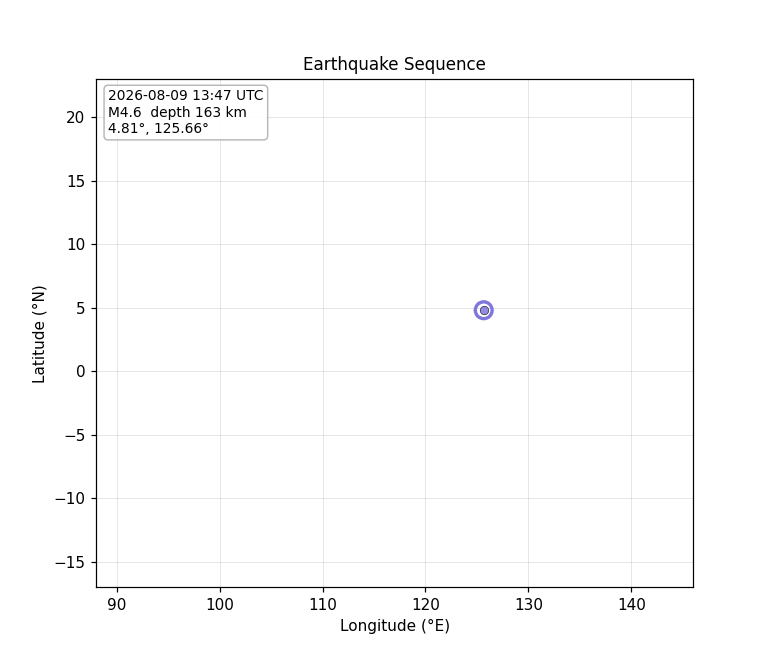

In [10]:
from IPython.display import Image
output_gif='earthquake_sequence.gif'
Image(open(output_gif, 'rb').read())